In [3]:
# Raw Data Loading
import pandas as pd

red_url = 'https://raw.githubusercontent.com/PinkWink/ML_tutorial' +\
                        '/master/dataset/winequality-red.csv'
white_url = 'https://raw.githubusercontent.com/PinkWink/ML_tutorial' +\
                        '/master/dataset/winequality-white.csv'
    
red_wine = pd.read_csv(red_url, sep = ';')
white_wine = pd.read_csv(white_url, sep = ";")

red_wine['color'] = 1
white_wine['color']= 0

wine = pd.concat([red_wine, white_wine])
wine['taste'] = [1. if grade > 5 else 0. for grade in wine['quality']]

x = wine.drop(['taste', 'quality'], axis = 1)
y = wine['taste']

In [4]:
# GridSearchCV를 통한 Hyperparameter Tuning
# DecisionTreeClassifier의 max_depth Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

params = {'max_depth': [2, 4, 7, 10]}
dtc = DecisionTreeClassifier(max_depth=2, random_state=13)

gridsearch = GridSearchCV(estimator=dtc, param_grid=params, cv=5)
gridsearch.fit(x, y)

GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(max_depth=2, random_state=13),
             param_grid={'max_depth': [2, 4, 7, 10]})

In [5]:
# 결과 출력
import pprint

pp = pprint.PrettyPrinter(indent=4)
pp.pprint(gridsearch.cv_results_)

{   'mean_fit_time': array([0.01069689, 0.01190181, 0.01699686, 0.02410164]),
    'mean_score_time': array([0.004002  , 0.00140157, 0.0015027 , 0.00160131]),
    'mean_test_score': array([0.6888005 , 0.66356523, 0.65340854, 0.64401587]),
    'param_max_depth': masked_array(data=[2, 4, 7, 10],
             mask=[False, False, False, False],
       fill_value=999999),
    'params': [   {'max_depth': 2},
                  {'max_depth': 4},
                  {'max_depth': 7},
                  {'max_depth': 10}],
    'rank_test_score': array([1, 2, 3, 4]),
    'split0_test_score': array([0.55230769, 0.51230769, 0.50846154, 0.51615385]),
    'split1_test_score': array([0.68846154, 0.63153846, 0.60307692, 0.60076923]),
    'split2_test_score': array([0.71439569, 0.72363356, 0.68360277, 0.66743649]),
    'split3_test_score': array([0.73210162, 0.73210162, 0.73672055, 0.71054657]),
    'split4_test_score': array([0.75673595, 0.7182448 , 0.73518091, 0.72517321]),
    'std_fit_time': array([0.00

In [ ]:
# best Hyperparameter 조합
gridsearch.best_estimator_

DecisionTreeClassifier(max_depth=2, random_state=13)

In [7]:
# best Score
gridsearch.best_score_

0.6888004974240539

In [9]:
# best Hyperparameter 조합
# max_depth=2 일 때 가장 성능이 좋음
gridsearch.best_params_

{'max_depth': 2}

In [10]:
# GridSearchCV Pipeline 적용
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

estimators = [
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(random_state=13))
]
pipe = Pipeline(estimators)

In [11]:
param_grid = [
    {'clf__max_depth': [2, 4, 7, 10]}
]

gridsearch = GridSearchCV(estimator=pipe, param_grid=param_grid, cv=5)
gridsearch.fit(x, y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('clf',
                                        DecisionTreeClassifier(random_state=13))]),
             param_grid=[{'clf__max_depth': [2, 4, 7, 10]}])

In [12]:
gridsearch.best_estimator_

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', DecisionTreeClassifier(max_depth=2, random_state=13))])

In [13]:
gridsearch.best_score_

0.6888004974240539

In [14]:
gridsearch.cv_results_

{'mean_fit_time': array([0.01651249, 0.01244664, 0.02137179, 0.03833079]),
 'std_fit_time': array([0.00873387, 0.00077654, 0.00502032, 0.00791042]),
 'mean_score_time': array([0.00308843, 0.00200038, 0.00183949, 0.00300751]),
 'std_score_time': array([0.00196719, 0.00089706, 0.0004131 , 0.00199627]),
 'param_clf__max_depth': masked_array(data=[2, 4, 7, 10],
              mask=[False, False, False, False],
        fill_value=999999),
 'params': [{'clf__max_depth': 2},
  {'clf__max_depth': 4},
  {'clf__max_depth': 7},
  {'clf__max_depth': 10}],
 'split0_test_score': array([0.55230769, 0.51230769, 0.50846154, 0.51615385]),
 'split1_test_score': array([0.68846154, 0.63153846, 0.60461538, 0.60230769]),
 'split2_test_score': array([0.71439569, 0.72363356, 0.68206313, 0.66589684]),
 'split3_test_score': array([0.73210162, 0.73210162, 0.73672055, 0.71054657]),
 'split4_test_score': array([0.75673595, 0.7182448 , 0.73518091, 0.72517321]),
 'mean_test_score': array([0.6888005 , 0.66356523, 0.653

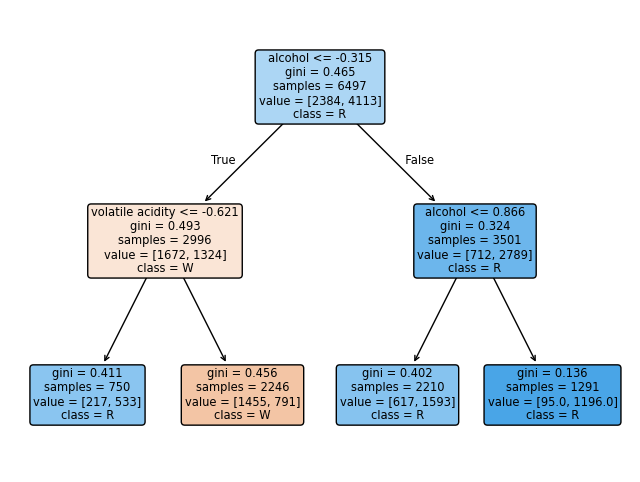

In [ ]:
# best Model tree plot
import matplotlib.pyplot as plt
from sklearn import tree

fig = plt.figure(figsize=(8, 6))
_ = tree.plot_tree(gridsearch.best_estimator_['clf'],
                   feature_names=list(x.columns),
                   class_names=['W', 'R'],
                   rounded=True,
                   filled=True)

In [16]:
score_df = pd.DataFrame(gridsearch.cv_results_)
score_df[['params', 'rank_test_score', 'mean_test_score', 'std_test_score']]

,params,rank_test_score,mean_test_score,std_test_score
0,{'clf__max_depth': 2},1,0.688800,0.071799
1,{'clf__max_depth': 4},2,0.663565,0.083905
2,{'clf__max_depth': 7},3,0.653408,0.086993
3,{'clf__max_depth': 10},4,0.644016,0.076915
